In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [2]:
df = pd.read_csv("Cricket_Fielding_Analysis.csv", header=1)

print(df.columns.tolist())

['Innings: 1st Innings  |  Team Fielding: Mumbai Indians  |  Venue: Wankhede Stadium  |  Date: 20 May 2023', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12']


In [3]:
# Rename columns

df.columns = [
    'Match_No',
    'Innings',
    'Team',
    'Player_Name',
    'Ball_Count',
    'Over_No',
    'Position',
    'Description',
    'Pick',
    'Throw',
    'Runs',
    'Venue',
    'Notes'
]

print(df.columns)

Index(['Match_No', 'Innings', 'Team', 'Player_Name', 'Ball_Count', 'Over_No',
       'Position', 'Description', 'Pick', 'Throw', 'Runs', 'Venue', 'Notes'],
      dtype='str')


In [4]:
# Convert Runs column into numeric

df['Runs'] = pd.to_numeric(df['Runs'], errors='coerce')

# Replace null values with 0
df['Runs'] = df['Runs'].fillna(0)

df.head()


,Match_No,Innings,Team,Player_Name,Ball_Count,Over_No,Position,Description,Pick,Throw,Runs,Venue,Notes
0,Match No.,Innings,Team,Player Name,Ball Count,Over No.,Position,Short Description,Pick\n(CP/GT/F/BT/C/DC),Throw\n(RO/MRO/ST/MST/DH),0.0,Venue,Notes
1,1,1,Mumbai Indians,Rohit Sharma,1,1,Mid-off,"Fielded a driven shot, clean pick and accurate...",Clean Pick,NaN,1.0,Wankhede,Good ground fielding
2,1,1,Mumbai Indians,Suryakumar Yadav,3,1,Cover,"Sprinted to stop a gap, fumbled the pick",Fumble,NaN,-1.0,Wankhede,Gave extra run
3,1,1,Mumbai Indians,Hardik Pandya,5,1,Mid-wicket,Direct hit attempt on non-striker — missed,NaN,Missed Run Out,-1.0,Wankhede,Narrowly missed
4,1,1,Mumbai Indians,Rohit Sharma,2,2,Point,Sharp catch off a mistimed cut shot,Catch,NaN,4.0,Wankhede,Excellent reflex catch


In [5]:
# Performance Score Function

def calculate_score(row):

    score = 0

    # PICK EVENTS
    if row['Pick'] == 'CP':
        score += 2

    elif row['Pick'] == 'GT':
        score += 3

    elif row['Pick'] == 'C':
        score += 5

    elif row['Pick'] == 'DC':
        score -= 5

    elif row['Pick'] == 'F':
        score -= 2

    # THROW EVENTS
    if row['Throw'] == 'RO':
        score += 6

    elif row['Throw'] == 'MRO':
        score -= 4

    elif row['Throw'] == 'DH':
        score += 4

    # RUNS SAVED
    score += row['Runs']

    return score


# Create Performance Score Column
df['Performance_Score'] = df.apply(calculate_score, axis=1)

df.head()

,Match_No,Innings,Team,Player_Name,Ball_Count,Over_No,Position,Description,Pick,Throw,Runs,Venue,Notes,Performance_Score
0,Match No.,Innings,Team,Player Name,Ball Count,Over No.,Position,Short Description,Pick\n(CP/GT/F/BT/C/DC),Throw\n(RO/MRO/ST/MST/DH),0.0,Venue,Notes,0.0
1,1,1,Mumbai Indians,Rohit Sharma,1,1,Mid-off,"Fielded a driven shot, clean pick and accurate...",Clean Pick,NaN,1.0,Wankhede,Good ground fielding,1.0
2,1,1,Mumbai Indians,Suryakumar Yadav,3,1,Cover,"Sprinted to stop a gap, fumbled the pick",Fumble,NaN,-1.0,Wankhede,Gave extra run,-1.0
3,1,1,Mumbai Indians,Hardik Pandya,5,1,Mid-wicket,Direct hit attempt on non-striker — missed,NaN,Missed Run Out,-1.0,Wankhede,Narrowly missed,-1.0
4,1,1,Mumbai Indians,Rohit Sharma,2,2,Point,Sharp catch off a mistimed cut shot,Catch,NaN,4.0,Wankhede,Excellent reflex catch,4.0


In [6]:
player_score = df.groupby('Player_Name')['Performance_Score'].sum()

print(player_score)

Player_Name
Hardik Pandya        9.0
Player Name          0.0
Rohit Sharma         3.0
Suryakumar Yadav    25.0
Name: Performance_Score, dtype: float64


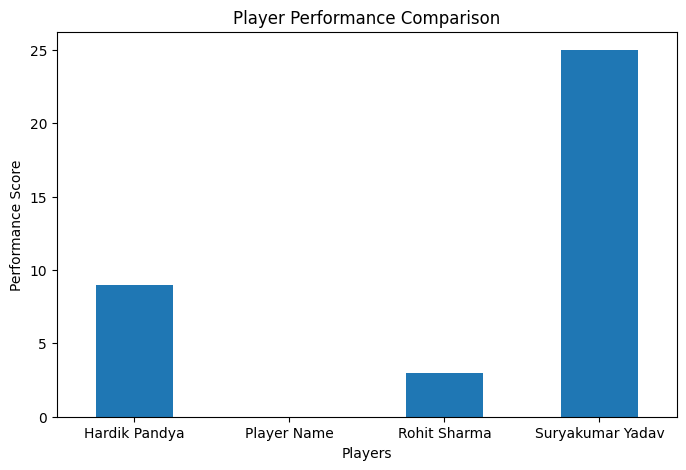

In [7]:
plt.figure(figsize=(8,5))

player_score.plot(kind='bar')

plt.title("Player Performance Comparison")

plt.xlabel("Players")

plt.ylabel("Performance Score")

plt.xticks(rotation=0)

plt.show()

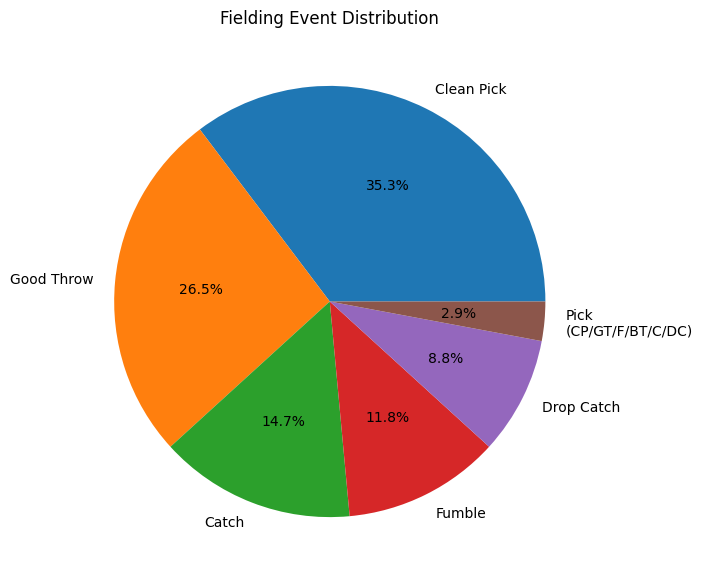

In [9]:
event_count = df['Pick'].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    event_count.values,
    labels=event_count.index,
    autopct='%1.1f%%'
)

plt.title("Fielding Event Distribution")

plt.show()

C:\Users\tahri\AppData\Local\Temp\ipykernel_2368\2725505643.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


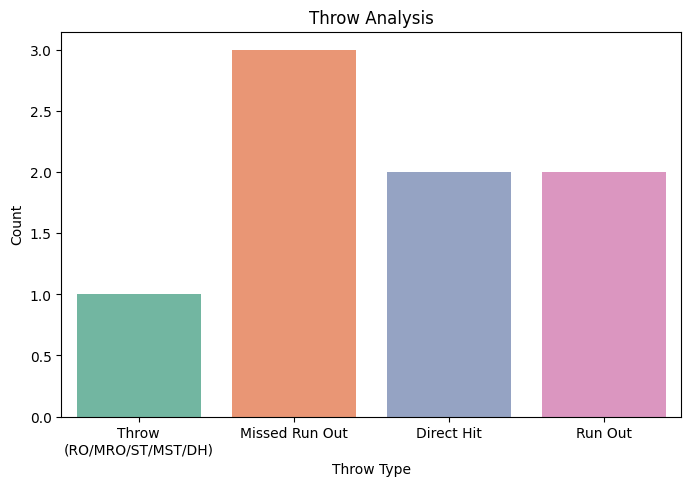

In [11]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Throw',
    data=df,
    palette='Set2'
)

plt.title("Throw Analysis")

plt.xlabel("Throw Type")

plt.ylabel("Count")

plt.show()

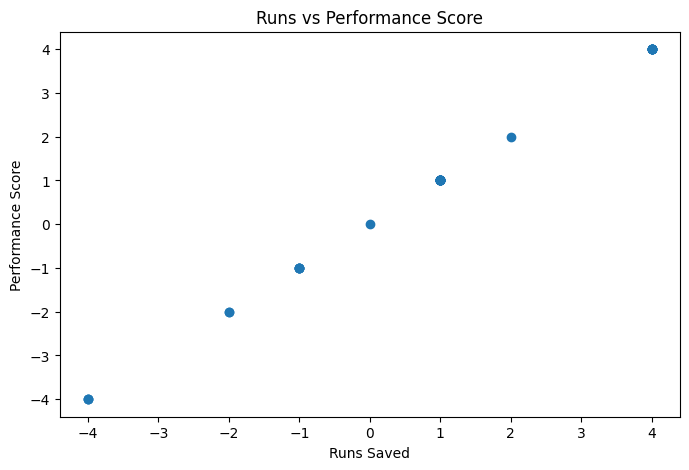

In [12]:
plt.figure(figsize=(8,5))

plt.scatter(
    df['Runs'],
    df['Performance_Score']
)

plt.title("Runs vs Performance Score")

plt.xlabel("Runs Saved")

plt.ylabel("Performance Score")

plt.show()

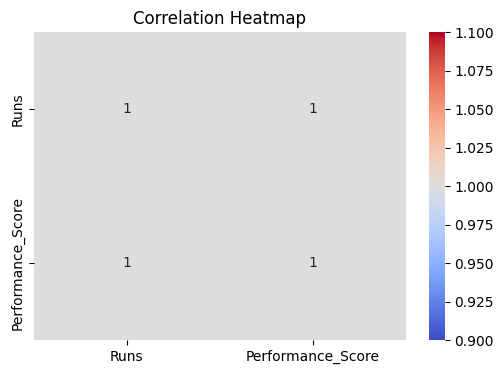

In [13]:
numeric_data = df[['Runs', 'Performance_Score']]

plt.figure(figsize=(6,4))

sns.heatmap(
    numeric_data.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()